# Final Chemical Data Merging

This notebook now does five things end to end:

1. Reads the transposed third sheet of the 1991 Detroit River chemical workbook.
2. Harmonizes the 1991 chemical units to the project defaults before merging, converting `mg/g` and `ng/g` values into `mg/kg` while keeping `%OC` in percent.
3. Uses the 1991 detection-limit row to replace `-` non-detects with reproducible random draws between $0.01 \times DL$ and $0.5 \times DL$ before merging.
4. Converts the later chemical workbook from $\log_2(x + 1)$ back to raw scale before merging.
5. Builds the final merged environmental, taxa, and chemical dataset by two routes, checks whether they are identical, maps the original site StationID values to the integrated codes in `ID_mapto_InterCode.xlsx`, and exports the checked final dataset as `complete_env_taxa_chemical_Apr17.xlsx` without the `2008_results` block.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.testing import assert_frame_equal

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
FINAL_MERGE_DIR = RAW_DIR / 'for_final_merging'
PROCESSED_DIR = DATA_DIR / 'processed'

PATHS = {
    'template': PROCESSED_DIR / 'complete_env_taxa_chemical_Feb_3.xlsx',
    'complete_env_taxa': PROCESSED_DIR / 'complete_env_taxa.xlsx',
    'environmental_raw': FINAL_MERGE_DIR / 'environmental_data_all_sites.xlsx',
    'taxa_raw': FINAL_MERGE_DIR / 'taxa_data_set_all_sites.xlsx',
    'chemical_log2': FINAL_MERGE_DIR / 'log_2_1p_chemical_data_255_sites.xlsx',
    'chemical_1991': FINAL_MERGE_DIR / '1991_Chemical_data_DR_sites.xls',
    'id_map': RAW_DIR / 'ID_mapto_InterCode.xlsx',
    'output_final': PROCESSED_DIR / 'complete_env_taxa_chemical_Apr17.xlsx',
}

MAP_LAYER_PATHS = {
    'lake_huron': DATA_DIR / 'maps' / 'lake_huron' / 'lake_huron.shp',
    'lake_stclair': DATA_DIR / 'maps' / 'lake_stclair' / 'lake_stclair.shp',
    'lake_erie': DATA_DIR / 'maps' / 'lake_erie' / 'lake_erie.shp',
    'stclair_aoc': DATA_DIR / 'maps' / 'aoc_mi_stclair_2021' / 'AOC_MI_StClair_2021.shp',
    'detroit_aoc': DATA_DIR / 'maps' / 'detroit_river_aoc_shapefile' / 'AOC_MI_Detroit_2021.shp',
}


def normalize_text(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    text = text.replace('‘', "'").replace('’', "'")
    text = text.replace('“', '"').replace('”', '"')
    text = re.sub(r'\s+', ' ', text)
    return text or None


def normalize_sheet_name(value):
    return re.sub(r'[^a-z0-9]+', '', str(value).lower())


def normalize_station_id(value):
    text = normalize_text(value)
    if not text:
        return None
    text = text.replace('*', '').replace('.0', '').strip()
    text = re.sub(r'\s+', '', text)
    if re.fullmatch(r'\d+', text):
        return str(int(text))
    return text


def normalize_1991_station_id(value):
    text = normalize_text(value)
    if not text:
        return None
    text = text.replace('*', '').replace('²', '').replace('§', '').replace('.0', '').strip().upper()
    text = re.sub(r'\s+', '', text)
    if text.startswith('PSQG') or text.startswith('OWDG'):
        return None
    if text == '20':
        return '200FB'
    if re.fullmatch(r'\d+', text):
        return f'{int(text)}FB'
    if re.fullmatch(r'[A-Z]+', text):
        return text
    if re.fullmatch(r'\d+[A-Z]+', text):
        return text
    return text


def normalize_parameter_label(value):
    text = normalize_text(value)
    return text.upper() if text else None


def parse_measurement(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    text = normalize_text(value)
    if text is None:
        return np.nan
    text = text.replace(',', '').replace('*', '')
    lowered = text.lower()
    if lowered in {'', 'nan', 'nm', 'na', 'n/a'}:
        return np.nan
    if lowered == '-' or text.startswith('<'):
        return 0.0
    match = re.search(r'-?\d+(?:\.\d+)?', text)
    return float(match.group()) if match else np.nan


TEMPLATE_DATA = pd.read_excel(PATHS['template'], header=[0, 1, 2], index_col=0)
TEMPLATE_DATA.index = pd.Index([normalize_station_id(index) for index in TEMPLATE_DATA.index], name='StationID')
TEMPLATE_DATA = TEMPLATE_DATA.sort_index()
TEMPLATE_COLUMNS = TEMPLATE_DATA.columns
FINAL_OUTPUT_COLUMNS = TEMPLATE_COLUMNS[TEMPLATE_COLUMNS.get_level_values(0) != '2008_results']
BASE_MERGE_COLUMNS = FINAL_OUTPUT_COLUMNS[FINAL_OUTPUT_COLUMNS.get_level_values(0) != 'chemical']
SAMPLE_INFO_VARS = TEMPLATE_DATA.loc[:, ('sample_info', 'raw', slice(None))].columns.get_level_values(-1).tolist()
ENVIRONMENTAL_VARS = TEMPLATE_DATA.loc[:, ('environmental', 'raw', slice(None))].columns.get_level_values(-1).tolist()
TAXA_VARS = TEMPLATE_DATA.loc[:, ('taxa', 'raw', slice(None))].columns.get_level_values(-1).tolist()
CANONICAL_CHEMICAL_VARS = TEMPLATE_DATA.loc[:, ('chemical', 'raw', slice(None))].columns.get_level_values(-1).tolist()

LOG2_TO_CANONICAL = {
    'L%OC': '%OC',
    'L1245TCB': '1245-TCB',
    'L1234TCB': '1234-TCB',
    'LQCB': 'QCB',
    'LHCB': 'HCB',
    'LOCS': 'OCS',
    'LDDE': "p,p'-DDE",
    'LSPCB': 'total PCB',
    'LAl': 'Al',
    'LAs': 'As',
    'LBi': 'Bi',
    'LCa': 'Ca',
    'LCd': 'Cd',
    'LCo': 'Co',
    'LCr': 'Cr',
    'LCu': 'Cu',
    'LFe': 'Fe',
    'LHg': 'Hg',
    'LK': 'K',
    'LMg': 'Mg',
    'LMn': 'Mn',
    'LNa': 'Na',
    'LNi': 'Ni',
    'LPb': 'Pb',
    'LSb': 'Sb',
    'LV': 'V',
    'LZn': 'Zn',
}

PARAMETER_TO_CANONICAL = {
    'TOC': '%OC',
    'ALUMINUM': 'Al',
    'ARSENIC': 'As',
    'CALCIUM': 'Ca',
    'CADMIUM': 'Cd',
    'COBALT': 'Co',
    'CHROMIUM': 'Cr',
    'COPPER': 'Cu',
    'IRON': 'Fe',
    'MERCURY': 'Hg',
    'MANGANESE': 'Mn',
    'NICKEL': 'Ni',
    'LEAD': 'Pb',
    'ZINC': 'Zn',
    'OCTACHLOROSTYRENE': 'OCS',
    'PCBS': 'total PCB',
    "P,P'-DDE": "p,p'-DDE",
}


def wrap_columns(df, level0, level1):
    wrapped = df.copy()
    wrapped.columns = pd.MultiIndex.from_tuples(
        [(level0, level1, column) for column in wrapped.columns],
        names=['block', 'subblock', 'var'],
    )
    return wrapped


def extract_block(df, level0, level1='raw'):
    block = df.loc[:, (level0, level1, slice(None))].copy()
    block.columns = block.columns.get_level_values(-1)
    return block


def get_matching_column(df, candidates):
    normalized = {normalize_sheet_name(column): column for column in df.columns}
    for candidate in candidates:
        candidate_key = normalize_sheet_name(candidate)
        if candidate_key in normalized:
            return normalized[candidate_key]
    raise KeyError(f'Could not find any of {candidates} in {df.columns.tolist()}')


def read_excel_sheet(path, candidate_names):
    xls = pd.ExcelFile(path)
    normalized = {normalize_sheet_name(sheet_name): sheet_name for sheet_name in xls.sheet_names}
    for candidate in candidate_names:
        candidate_key = normalize_sheet_name(candidate)
        if candidate_key in normalized:
            actual_sheet = normalized[candidate_key]
            return pd.read_excel(path, sheet_name=actual_sheet), actual_sheet
    raise KeyError(f'Could not find any of {candidate_names} in sheets {xls.sheet_names}')


def standardize_station_index(df):
    station_column = get_matching_column(df, ['StationID', 'Station ID', 'Station'])
    standardized = df.copy()
    standardized[station_column] = standardized[station_column].map(normalize_station_id)
    standardized = standardized.dropna(subset=[station_column]).set_index(station_column)
    standardized.index.name = 'StationID'
    return standardized


def load_integrated_code_mapping():
    mapping = pd.read_excel(PATHS['id_map']).dropna(how='all')
    station_column = get_matching_column(mapping, ['Station No ID  (Zhang)', 'Station No ID (Zhang)', 'StationID'])
    integrated_code_column = get_matching_column(mapping, ['Integrated Code', 'Integrated code'])
    mapping = mapping[[station_column, integrated_code_column]].copy()
    mapping[station_column] = mapping[station_column].map(normalize_station_id)
    mapping[integrated_code_column] = mapping[integrated_code_column].map(normalize_text)
    mapping = mapping.dropna(subset=[station_column, integrated_code_column]).drop_duplicates(subset=[station_column], keep='first')
    if mapping[station_column].duplicated().any():
        duplicates = mapping.loc[mapping[station_column].duplicated(), station_column].tolist()
        raise ValueError(f'Duplicate StationID entries in integrated-code mapping: {duplicates}')
    lookup = mapping.set_index(station_column)[integrated_code_column].to_dict()
    return lookup, mapping.rename(columns={station_column: 'StationID', integrated_code_column: 'Integrated Code'})


def summarize_mapping_coverage(index_values, lookup):
    normalized_ids = [normalize_station_id(value) for value in index_values]
    unmapped = [station_id for station_id in normalized_ids if station_id not in lookup]
    return {
        'total': len(normalized_ids),
        'mapped': len(normalized_ids) - len(unmapped),
        'unmapped': len(unmapped),
        'example_unmapped': unmapped[:20],
    }


def build_env_taxa_from_raw():
    environmental_raw, environmental_sheet = read_excel_sheet(PATHS['environmental_raw'], ['all_samples', 'all samples'])
    taxa_raw, taxa_sheet = read_excel_sheet(PATHS['taxa_raw'], ['all_samples', 'all samples'])

    environmental = standardize_station_index(environmental_raw)
    taxa = standardize_station_index(taxa_raw)

    common_index = environmental.index.intersection(taxa.index).sort_values()
    environmental = environmental.loc[common_index].copy()
    taxa = taxa.loc[common_index].copy()

    sample_info = environmental.reindex(columns=SAMPLE_INFO_VARS)
    environmental_block = environmental.reindex(columns=ENVIRONMENTAL_VARS)
    taxa_block = taxa.reindex(columns=TAXA_VARS)

    merged = pd.concat(
        [
            wrap_columns(sample_info, 'sample_info', 'raw'),
            wrap_columns(environmental_block, 'environmental', 'raw'),
            wrap_columns(taxa_block, 'taxa', 'raw'),
        ],
        axis=1,
    )
    merged = merged.reindex(columns=BASE_MERGE_COLUMNS)
    merged.index.name = 'StationID'

    diagnostics = {
        'environmental_sheet': environmental_sheet,
        'taxa_sheet': taxa_sheet,
        'environmental_rows': len(environmental_raw),
        'taxa_rows': len(taxa_raw),
        'merged_rows': len(merged),
    }
    return merged.sort_index(), diagnostics


def build_raw_scale_chemical_tables():
    chemical = pd.read_excel(PATHS['chemical_log2'])
    primary_station_column = get_matching_column(chemical, ['Station No ID  (Zhang)', 'Station No ID (Zhang)'])
    fallback_station_column = get_matching_column(chemical, ['Site Names (all sources)', 'Site Names'])

    chemical = chemical.copy()
    chemical['StationID'] = chemical[primary_station_column].fillna(chemical[fallback_station_column]).map(normalize_station_id)
    chemical = chemical.dropna(subset=['StationID'])
    chemical = chemical[['StationID', *LOG2_TO_CANONICAL.keys()]].copy()
    chemical = chemical.dropna(subset=list(LOG2_TO_CANONICAL.keys()))
    chemical = chemical.rename(columns=LOG2_TO_CANONICAL).set_index('StationID')
    chemical = chemical.reindex(columns=CANONICAL_CHEMICAL_VARS)
    chemical.index.name = 'StationID'
    if chemical.index.duplicated().any():
        raise ValueError('Duplicate StationID values found in the log2 chemical dataset')

    restored_raw = np.power(2.0, chemical.astype(float)) - 1.0
    restored_raw = restored_raw.mask(np.isclose(restored_raw, 0.0, atol=1e-12), 0.0)
    restored_raw.index.name = 'StationID'
    return chemical.sort_index(), restored_raw.sort_index()


def extract_1991_table(raw_df, label_column, data_start_column):
    normalized_labels = raw_df.iloc[:, label_column].map(normalize_parameter_label)
    station_headers = raw_df.iloc[3, data_start_column:]
    records = {}

    for column_index, header in station_headers.items():
        station_id = normalize_1991_station_id(header)
        if station_id is None:
            continue
        record = {}
        for source_label, final_label in PARAMETER_TO_CANONICAL.items():
            row_mask = normalized_labels == normalize_parameter_label(source_label)
            if not row_mask.any():
                continue
            row_index = row_mask[row_mask].index[0]
            record[final_label] = parse_measurement(raw_df.iat[row_index, column_index])
        records[station_id] = record

    extracted = pd.DataFrame.from_dict(records, orient='index')
    extracted.index.name = 'StationID'
    return extracted.sort_index()


def build_1991_chemical_table():
    raw_df = pd.read_excel(PATHS['chemical_1991'], header=None)
    left_table = extract_1991_table(raw_df, label_column=0, data_start_column=4)
    right_table = extract_1991_table(raw_df, label_column=44, data_start_column=48)
    combined_raw = pd.concat([left_table, right_table], axis=0)
    if combined_raw.index.duplicated().any():
        combined_raw = combined_raw.groupby(level=0).first()
    combined_raw = combined_raw.reindex(columns=CANONICAL_CHEMICAL_VARS)
    combined_raw.index.name = 'StationID'
    return combined_raw.sort_index()


def build_combined_chemical_table(target_index):
    later_chemical_log2, later_chemical_raw = build_raw_scale_chemical_tables()
    chemical_1991_raw = build_1991_chemical_table()
    combined_raw = later_chemical_raw.combine_first(chemical_1991_raw)
    combined_raw = combined_raw.reindex(target_index).reindex(columns=CANONICAL_CHEMICAL_VARS)
    combined_raw.index.name = 'StationID'
    diagnostics = {
        'later_log2_rows': len(later_chemical_log2),
        'later_raw_rows': len(later_chemical_raw),
        'raw_1991_rows': len(chemical_1991_raw),
        'combined_rows_with_any_chemical': int(combined_raw.notna().any(axis=1).sum()),
        'present_1991_columns': [column for column in CANONICAL_CHEMICAL_VARS if chemical_1991_raw[column].notna().any()],
        'missing_1991_columns': [column for column in CANONICAL_CHEMICAL_VARS if not chemical_1991_raw[column].notna().any()],
    }
    return later_chemical_log2, later_chemical_raw, chemical_1991_raw, combined_raw, diagnostics


def merge_env_taxa_with_chemical(env_taxa_df, chemical_df):
    chemical_block = wrap_columns(chemical_df.reindex(env_taxa_df.index), 'chemical', 'raw')
    merged = pd.concat([env_taxa_df.reindex(columns=BASE_MERGE_COLUMNS), chemical_block], axis=1)
    merged = merged.reindex(columns=FINAL_OUTPUT_COLUMNS)
    merged.index.name = 'StationID'
    return merged.sort_index()


def load_corridor_layers():
    layers = {}
    for name, path in MAP_LAYER_PATHS.items():
        layer = gpd.read_file(path)
        if layer.crs is not None:
            layer = layer.to_crs(4326)
        layers[name] = layer
    return layers


def plot_corridor_background(ax):
    water_color = '#cfe9f3'
    edge_color = '#9bc7d8'
    for layer_name in ['lake_huron', 'lake_stclair', 'lake_erie', 'stclair_aoc', 'detroit_aoc']:
        CORRIDOR_LAYERS[layer_name].plot(ax=ax, color=water_color, edgecolor=edge_color, linewidth=0.5, alpha=0.9)
    ax.set_xlim(-83.3, -82.35)
    ax.set_ylim(42.0, 43.2)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')


def block_presence_mask(df, block_name):
    block = extract_block(df, block_name)
    return block.notna().any(axis=1)


def plot_sampling_locations(df, dataset_label):
    sample_info = extract_block(df, 'sample_info')
    sampling_specs = [
        ('chemical', '#ff3b30', 'Chemical Sampling'),
        ('environmental', '#2454ff', 'Environmental Sampling'),
        ('taxa', '#14923b', 'Taxa Sampling'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(11.5, 5), sharey=True, constrained_layout=True)

    for ax, (block_name, base_color, legend_prefix) in zip(axes, sampling_specs):
        plot_corridor_background(ax)
        mask = block_presence_mask(df, block_name)
        plot_data = sample_info.loc[mask, ['Longitude', 'Latitude']].dropna(subset=['Longitude', 'Latitude']).copy()
        plot_gdf = gpd.GeoDataFrame(
            plot_data,
            geometry=gpd.points_from_xy(plot_data['Longitude'], plot_data['Latitude']),
            crs='EPSG:4326',
        )
        plot_gdf.plot(ax=ax, color=base_color, markersize=8, label=legend_prefix)

        ax.set_title(f'Total observation: {len(plot_data)}', fontsize=11)
        ax.text(-82.85, 42.42, 'Lake Saint Clair', fontsize=8, color='gray', weight='bold', alpha=0.55)
        ax.text(-83.07, 42.20, 'Detroit River', fontsize=8, color='gray', weight='bold', alpha=0.55)
        ax.text(-82.92, 42.90, 'Saint Clair River', fontsize=8, color='gray', weight='bold', alpha=0.55)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.45)

    fig.suptitle(dataset_label, fontsize=13)
    return fig


CORRIDOR_LAYERS = load_corridor_layers()

In [2]:
def load_integrated_code_mapping():
    expected_station_candidates = ['Station No ID  (Zhang)', 'Station No ID (Zhang)', 'StationID']
    expected_code_candidates = ['Integrated Code', 'Integrated code']

    mapping = pd.read_excel(PATHS['id_map']).dropna(how='all')

    try:
        station_column = get_matching_column(mapping, expected_station_candidates)
        integrated_code_column = get_matching_column(mapping, expected_code_candidates)
    except KeyError:
        mapping_raw = pd.read_excel(PATHS['id_map'], header=None).dropna(how='all')
        header_row_index = None

        for row_index in mapping_raw.index[:10]:
            row_values = [normalize_text(value) for value in mapping_raw.loc[row_index].tolist()]
            normalized_row = {
                normalize_sheet_name(value): value
                for value in row_values
                if value is not None
            }
            has_station_column = any(normalize_sheet_name(candidate) in normalized_row for candidate in expected_station_candidates)
            has_code_column = any(normalize_sheet_name(candidate) in normalized_row for candidate in expected_code_candidates)
            if has_station_column and has_code_column:
                header_row_index = row_index
                break

        if header_row_index is None:
            raise

        header_values = [normalize_text(value) for value in mapping_raw.loc[header_row_index].tolist()]
        mapping = mapping_raw.loc[header_row_index + 1 :].copy()
        mapping.columns = header_values

        station_column = get_matching_column(mapping, expected_station_candidates)
        integrated_code_column = get_matching_column(mapping, expected_code_candidates)

    mapping = mapping[[station_column, integrated_code_column]].copy()
    mapping[station_column] = mapping[station_column].map(normalize_station_id)
    mapping[integrated_code_column] = mapping[integrated_code_column].map(normalize_text)
    mapping = mapping.dropna(subset=[station_column, integrated_code_column]).drop_duplicates(subset=[station_column], keep='first')

    if mapping[station_column].duplicated().any():
        duplicates = mapping.loc[mapping[station_column].duplicated(), station_column].tolist()
        raise ValueError(f'Duplicate StationID entries in integrated-code mapping: {duplicates}')

    lookup = mapping.set_index(station_column)[integrated_code_column].to_dict()
    return lookup, mapping.rename(columns={station_column: 'StationID', integrated_code_column: 'Integrated Code'})

In [3]:
TRANSPOSED_1991_TO_CANONICAL = {
    'TOC': '%OC',
    'CALCIUM': 'Ca',
    'ALUMINUM': 'Al',
    'ARSENIC': 'As',
    'CADMIUM': 'Cd',
    'COBALT': 'Co',
    'CHROMIUM': 'Cr',
    'COPPER': 'Cu',
    'IRON': 'Fe',
    'MERCURY': 'Hg',
    'MANGANESE': 'Mn',
    'NICKEL': 'Ni',
    'LEAD': 'Pb',
    'ZINC': 'Zn',
    'OCTACHLOROSTYRENE': 'OCS',
    'PCBS': 'total PCB',
    "P,P'-DDE": "p,p'-DDE",
}

UNIT_SCALE_TO_TARGET = {
    'mg/kg': 1.0,
    'ug/g': 1.0,
    'mg/g': 1000.0,
    'ng/g': 0.001,
    '%': 1.0,
}

DETECTION_FILL_SEED = 2006


def is_non_detect_marker(value):
    text = normalize_text(value)
    return text == '-'


def normalize_unit_label(value):
    text = normalize_text(value)
    if not text:
        return None
    return text.replace('μ', 'u').replace('µ', 'u').replace(' ', '').lower()


def parse_transposed_measurement(value):
    if pd.isna(value):
        return np.nan
    text = normalize_text(value)
    if text is None:
        return np.nan
    lowered = text.lower()
    if lowered in {'', 'nan', 'na', 'n/a', 'nm'}:
        return np.nan
    if text == '-':
        return np.nan
    match = re.search(r'-?\d+(?:\.\d+)?', text)
    return float(match.group()) if match else np.nan


def read_1991_transposed_sheet():
    xls = pd.ExcelFile(PATHS['chemical_1991'])
    normalized = {normalize_sheet_name(sheet_name): sheet_name for sheet_name in xls.sheet_names}
    for candidate in ['tranposed', 'transposed']:
        if candidate in normalized:
            actual_sheet = normalized[candidate]
            return pd.read_excel(PATHS['chemical_1991'], sheet_name=actual_sheet, header=None), actual_sheet
    raise KeyError(f"Could not find the transposed 1991 sheet in {xls.sheet_names}")


def get_target_unit_and_scale(canonical_var, raw_unit):
    normalized_unit = normalize_unit_label(raw_unit)
    if canonical_var == '%OC':
        if normalized_unit != '%':
            raise ValueError(f"Expected % unit for %OC in the 1991 sheet, got {raw_unit!r}")
        return '%', 1.0
    if normalized_unit not in UNIT_SCALE_TO_TARGET:
        raise ValueError(f"Unsupported 1991 unit {raw_unit!r} for chemical {canonical_var}")
    if normalized_unit == '%':
        raise ValueError(f"Unexpected percent unit for chemical {canonical_var}")
    return 'mg/kg', UNIT_SCALE_TO_TARGET[normalized_unit]


def build_1991_chemical_table():
    raw_df, sheet_name = read_1991_transposed_sheet()
    header_row = raw_df.iloc[0]
    unit_row = raw_df.iloc[1]
    first_column = raw_df.iloc[:, 0].map(normalize_text)
    detection_matches = first_column[first_column == 'Detection Limit']
    if detection_matches.empty:
        raise KeyError('Could not find the Detection Limit row in the transposed 1991 sheet')

    detection_row_index = detection_matches.index[0]
    detection_row = raw_df.loc[detection_row_index]
    site_rows = raw_df.iloc[2:detection_row_index].copy()

    station_column_index = next(
        column_index
        for column_index, header_value in header_row.items()
        if normalize_parameter_label(header_value) == normalize_parameter_label('Station No ID  (Zhang)')
    )

    site_rows['StationID'] = site_rows.iloc[:, station_column_index].map(normalize_station_id)
    site_rows = site_rows.dropna(subset=['StationID']).set_index('StationID')
    site_rows.index.name = 'StationID'
    site_rows = site_rows.loc[~site_rows.index.duplicated(keep='first')].copy()

    standardized = pd.DataFrame(index=site_rows.index)
    filled = pd.DataFrame(index=site_rows.index)
    unit_summary_records = []
    fill_summary_records = []
    fill_example_records = []
    rng = np.random.default_rng(DETECTION_FILL_SEED)

    for column_index, header_value in header_row.items():
        source_name = normalize_parameter_label(header_value)
        canonical_var = TRANSPOSED_1991_TO_CANONICAL.get(source_name)
        if canonical_var is None:
            continue

        target_unit, scale_factor = get_target_unit_and_scale(canonical_var, unit_row.iloc[column_index])
        source_values = site_rows.iloc[:, column_index]
        non_detect_mask = source_values.map(is_non_detect_marker)
        standardized_values = source_values.map(parse_transposed_measurement).astype(float) * scale_factor
        filled_values = standardized_values.copy()

        detection_limit_source = parse_transposed_measurement(detection_row.iloc[column_index])
        detection_limit_target = detection_limit_source * scale_factor if pd.notna(detection_limit_source) else np.nan
        under_detection_count = int(non_detect_mask.sum())
        filled_count = 0
        imputed_min = np.nan
        imputed_max = np.nan

        if under_detection_count > 0 and pd.notna(detection_limit_target):
            imputed_values = rng.uniform(
                detection_limit_target * 0.01,
                detection_limit_target * 0.5,
                size=under_detection_count,
            )
            filled_values.loc[non_detect_mask] = imputed_values
            filled_count = int(len(imputed_values))
            imputed_min = float(np.min(imputed_values))
            imputed_max = float(np.max(imputed_values))

            for station_id, imputed_value in zip(filled_values.index[non_detect_mask], imputed_values):
                fill_example_records.append(
                    {
                        'StationID': station_id,
                        'canonical_var': canonical_var,
                        'source_name': normalize_text(header_value),
                        'target_unit': target_unit,
                        'detection_limit': detection_limit_target,
                        'filled_value': float(imputed_value),
                    }
                )

        standardized[canonical_var] = standardized_values
        filled[canonical_var] = filled_values

        unit_summary_records.append(
            {
                'source_name': normalize_text(header_value),
                'canonical_var': canonical_var,
                'source_unit': normalize_text(unit_row.iloc[column_index]),
                'target_unit': target_unit,
                'scale_factor': scale_factor,
                'detection_limit_source': detection_limit_source,
                'detection_limit_target': detection_limit_target,
                'under_detection_count': under_detection_count,
                'filled_count': filled_count,
            }
        )

        if under_detection_count > 0:
            fill_summary_records.append(
                {
                    'source_name': normalize_text(header_value),
                    'canonical_var': canonical_var,
                    'target_unit': target_unit,
                    'detection_limit_target': detection_limit_target,
                    'under_detection_count': under_detection_count,
                    'filled_count': filled_count,
                    'imputed_min': imputed_min,
                    'imputed_max': imputed_max,
                }
            )

    standardized = standardized.reindex(columns=CANONICAL_CHEMICAL_VARS).sort_index()
    filled = filled.reindex(columns=CANONICAL_CHEMICAL_VARS).sort_index()

    unit_summary = pd.DataFrame(unit_summary_records).sort_values(['canonical_var']).reset_index(drop=True)
    fill_summary = pd.DataFrame(fill_summary_records).sort_values(['canonical_var']).reset_index(drop=True)
    fill_examples = pd.DataFrame(fill_example_records).sort_values(['canonical_var', 'StationID']).reset_index(drop=True)

    diagnostics = {
        'sheet_name': sheet_name,
        'site_rows': len(filled),
        'unit_summary': unit_summary,
        'fill_summary': fill_summary,
        'fill_examples': fill_examples,
        'filled_non_detect_cells': int(fill_summary['filled_count'].sum()) if not fill_summary.empty else 0,
        'scaled_chemicals': unit_summary.loc[unit_summary['scale_factor'] != 1.0, 'canonical_var'].tolist(),
        'filled_chemicals': fill_summary.loc[fill_summary['filled_count'] > 0, 'canonical_var'].tolist() if not fill_summary.empty else [],
    }
    return standardized, filled, diagnostics


def build_combined_chemical_table(target_index):
    later_chemical_log2, later_chemical_raw = build_raw_scale_chemical_tables()
    chemical_1991_standardized, chemical_1991_filled, chemical_1991_diagnostics = build_1991_chemical_table()
    combined_raw = later_chemical_raw.combine_first(chemical_1991_filled)
    combined_raw = combined_raw.reindex(target_index).reindex(columns=CANONICAL_CHEMICAL_VARS)
    combined_raw.index.name = 'StationID'

    diagnostics = {
        'later_log2_rows': len(later_chemical_log2),
        'later_raw_rows': len(later_chemical_raw),
        'raw_1991_rows': len(chemical_1991_filled),
        'combined_rows_with_any_chemical': int(combined_raw.notna().any(axis=1).sum()),
        'present_1991_columns': [column for column in CANONICAL_CHEMICAL_VARS if chemical_1991_filled[column].notna().any()],
        'missing_1991_columns': [column for column in CANONICAL_CHEMICAL_VARS if not chemical_1991_filled[column].notna().any()],
        '1991_sheet': chemical_1991_diagnostics['sheet_name'],
        'chemical_1991_unit_summary': chemical_1991_diagnostics['unit_summary'],
        'chemical_1991_fill_summary': chemical_1991_diagnostics['fill_summary'],
        'chemical_1991_fill_examples': chemical_1991_diagnostics['fill_examples'],
        'filled_non_detect_cells': chemical_1991_diagnostics['filled_non_detect_cells'],
        'scaled_1991_chemicals': chemical_1991_diagnostics['scaled_chemicals'],
        'filled_1991_chemicals': chemical_1991_diagnostics['filled_chemicals'],
        'detection_fill_seed': DETECTION_FILL_SEED,
    }
    return (
        later_chemical_log2.sort_index(),
        later_chemical_raw.sort_index(),
        chemical_1991_standardized.sort_index(),
        chemical_1991_filled.sort_index(),
        combined_raw.sort_index(),
        diagnostics,
    )

In [4]:
def map_index_with_integrated_codes(df, lookup):
    mapped_index = []
    unmapped = []
    for station_id in df.index:
        normalized_station_id = normalize_station_id(station_id)
        mapped_code = lookup.get(normalized_station_id)
        if mapped_code is None:
            mapped_index.append(normalized_station_id)
            unmapped.append(normalized_station_id)
        else:
            mapped_index.append(mapped_code)
    mapped_df = df.copy()
    mapped_df.index = pd.Index(mapped_index, name='StationID')
    duplicate_codes = mapped_df.index[mapped_df.index.duplicated()].unique().tolist()
    diagnostics = {
        'total': len(mapped_df),
        'mapped': len(mapped_df) - len(unmapped),
        'unmapped': len(unmapped),
        'example_unmapped': unmapped[:20],
        'duplicate_count': len(duplicate_codes),
        'example_duplicate_codes': duplicate_codes[:20],
    }
    return mapped_df, diagnostics


integrated_code_lookup, integrated_code_table = load_integrated_code_mapping()
complete_env_taxa_base = pd.read_excel(PATHS['complete_env_taxa'], header=[0, 1, 2], index_col=0)
complete_env_taxa_base = complete_env_taxa_base.reindex(columns=BASE_MERGE_COLUMNS).sort_index()
complete_env_taxa_base.index = pd.Index([normalize_station_id(index) for index in complete_env_taxa_base.index], name='StationID')
complete_env_taxa_base = complete_env_taxa_base.sort_index()

mapping_diagnostics = summarize_mapping_coverage(complete_env_taxa_base.index, integrated_code_lookup)
(
    later_chemical_log2_values,
    later_chemical_raw_values,
    chemical_1991_standardized_values,
    chemical_1991_raw_values,
    combined_chemical,
    chemical_diagnostics,
) = build_combined_chemical_table(complete_env_taxa_base.index)
chemical_1991_unit_summary = chemical_diagnostics['chemical_1991_unit_summary']
chemical_1991_fill_summary = chemical_diagnostics['chemical_1991_fill_summary']
chemical_1991_fill_examples = chemical_diagnostics['chemical_1991_fill_examples']
example_station = later_chemical_raw_values['Al'].dropna().index[0]
example_1991_station = chemical_1991_raw_values['Al'].dropna().index[0]

print('Template rows/cols:', TEMPLATE_DATA.shape)
print('complete_env_taxa rows/cols after dropping 2008_results:', complete_env_taxa_base.shape)
print('Later chemical workbook is stored as log2(x + 1), then restored to raw scale before merging.')
print(f"Example restored later-chemical value at station {example_station}: log2 Al = {later_chemical_log2_values.at[example_station, 'Al']:.3f}, raw Al = {later_chemical_raw_values.at[example_station, 'Al']:.3f}")
print(f"Example 1991 raw Al at station {example_1991_station}: standardized Al = {chemical_1991_standardized_values.at[example_1991_station, 'Al']:.3f}, merged Al = {chemical_1991_raw_values.at[example_1991_station, 'Al']:.3f}")
print('1991 chemical sheet used:', chemical_diagnostics['1991_sheet'])
print('1991 rows parsed from the transposed workbook:', chemical_diagnostics['raw_1991_rows'])
print('1991 chemicals scaled into mg/kg before merging:', chemical_diagnostics['scaled_1991_chemicals'])
print('1991 under-detection cells filled from the Detection Limit row:', chemical_diagnostics['filled_non_detect_cells'])
print('1991 chemicals with filled under-detection values:', chemical_diagnostics['filled_1991_chemicals'])
print(f"Detection-limit fill seed: {chemical_diagnostics['detection_fill_seed']} (uniform draws from 0.01×DL to 0.5×DL)")
print('Rows with any raw chemical data after combining later + 1991 sources:', chemical_diagnostics['combined_rows_with_any_chemical'])
print('1991 chemical variables available in the workbook:', chemical_diagnostics['present_1991_columns'])
print('1991 chemical variables not available in the workbook:', chemical_diagnostics['missing_1991_columns'])
print('Integrated-code mapping entries:', len(integrated_code_table))
print('Station IDs mapped to integrated codes:', mapping_diagnostics['mapped'])
print('Station IDs still unmapped:', mapping_diagnostics['unmapped'])
print('Example unmapped StationIDs:', mapping_diagnostics['example_unmapped'])
if not chemical_1991_fill_examples.empty:
    example_fill = chemical_1991_fill_examples.iloc[0]
    print(
        f"Example filled non-detect: {example_fill['StationID']} {example_fill['canonical_var']} = "
        f"{example_fill['filled_value']:.6f} {example_fill['target_unit']} (DL={example_fill['detection_limit']:.6f})"
    )
if mapping_diagnostics['unmapped'] == 0:
    print('The updated mapping workbook now covers every StationID in the merged dataset.')
else:
    print("The mapping workbook leaves some StationIDs without integrated codes, so those IDs stay unchanged in the final export.")

Template rows/cols: (233, 56)
complete_env_taxa rows/cols after dropping 2008_results: (311, 26)
Later chemical workbook is stored as log2(x + 1), then restored to raw scale before merging.
Example restored later-chemical value at station 001A: log2 Al = 13.173, raw Al = 9232.497
Example 1991 raw Al at station 10FB: standardized Al = 5300.000, merged Al = 5300.000
1991 chemical sheet used: Tranposed
1991 rows parsed from the transposed workbook: 77
1991 chemicals scaled into mg/kg before merging: ['Al', 'Ca', 'Fe', 'OCS', "p,p'-DDE", 'total PCB']
1991 under-detection cells filled from the Detection Limit row: 163
1991 chemicals with filled under-detection values: ['Cd', 'Hg', 'OCS', "p,p'-DDE", 'total PCB']
Detection-limit fill seed: 2006 (uniform draws from 0.01×DL to 0.5×DL)
Rows with any raw chemical data after combining later + 1991 sources: 310
1991 chemical variables available in the workbook: ['%OC', 'OCS', "p,p'-DDE", 'total PCB', 'Al', 'As', 'Ca', 'Cd', 'Co', 'Cr', 'Cu', 'Fe',

In [5]:
master_merged = merge_env_taxa_with_chemical(complete_env_taxa_base, combined_chemical)
master_merged_mapped, master_mapping_diagnostics = map_index_with_integrated_codes(master_merged, integrated_code_lookup)

print('Master-based merged shape:', master_merged_mapped.shape)
print('Master-based rows with any chemical data:', int(block_presence_mask(master_merged_mapped, 'chemical').sum()))
print('Master-based mapped StationIDs:', master_mapping_diagnostics['mapped'])
print('Master-based unmapped StationIDs:', master_mapping_diagnostics['unmapped'])
print('Master-based duplicate integrated codes:', master_mapping_diagnostics['duplicate_count'])
print('Example duplicate integrated codes:', master_mapping_diagnostics['example_duplicate_codes'])
print('Example unmapped StationIDs:', master_mapping_diagnostics['example_unmapped'])
print('First 10 mapped StationIDs:', master_merged_mapped.index[:10].tolist())

Master-based merged shape: (311, 53)
Master-based rows with any chemical data: 310
Master-based mapped StationIDs: 311
Master-based unmapped StationIDs: 0
Master-based duplicate integrated codes: 0
Example duplicate integrated codes: []
Example unmapped StationIDs: []
First 10 mapped StationIDs: ['DR-02', 'DR-03', 'DR-04', 'DR-06', 'DR-07', 'DR-08', 'DR-09', 'DR-10', 'DR-21', 'DR-32']


In [6]:
raw_env_taxa, raw_env_taxa_diagnostics = build_env_taxa_from_raw()
raw_merged = merge_env_taxa_with_chemical(raw_env_taxa, combined_chemical.reindex(raw_env_taxa.index))
raw_merged_mapped, raw_mapping_diagnostics = map_index_with_integrated_codes(raw_merged, integrated_code_lookup)

raw_env_taxa_matches_processed = True
raw_env_taxa_message = 'The raw environmental/taxa rebuild matches complete_env_taxa.xlsx once 2008_results is removed.'
try:
    assert_frame_equal(raw_env_taxa, complete_env_taxa_base, check_dtype=False)
except AssertionError as exc:
    raw_env_taxa_matches_processed = False
    raw_env_taxa_message = str(exc).splitlines()[0]

print('Raw merge source sheets:', raw_env_taxa_diagnostics)
print('Raw-file merged shape:', raw_merged_mapped.shape)
print('Raw environmental/taxa rebuild matches processed complete_env_taxa without 2008_results:', raw_env_taxa_matches_processed)
print(raw_env_taxa_message)
print('Raw-file mapped StationIDs:', raw_mapping_diagnostics['mapped'])
print('Raw-file unmapped StationIDs:', raw_mapping_diagnostics['unmapped'])
print('Raw-file duplicate integrated codes:', raw_mapping_diagnostics['duplicate_count'])
print('Example duplicate integrated codes:', raw_mapping_diagnostics['example_duplicate_codes'])
print('Example unmapped StationIDs:', raw_mapping_diagnostics['example_unmapped'])

Raw merge source sheets: {'environmental_sheet': 'all_samples', 'taxa_sheet': 'all_samples', 'environmental_rows': 323, 'taxa_rows': 311, 'merged_rows': 311}
Raw-file merged shape: (311, 53)
Raw environmental/taxa rebuild matches processed complete_env_taxa without 2008_results: True
The raw environmental/taxa rebuild matches complete_env_taxa.xlsx once 2008_results is removed.
Raw-file mapped StationIDs: 311
Raw-file unmapped StationIDs: 0
Raw-file duplicate integrated codes: 0
Example duplicate integrated codes: []
Example unmapped StationIDs: []


In [7]:
final_outputs_equal = True
final_outputs_message = 'No cell-level differences detected between the mapped master-based and raw-file merged outputs.'
try:
    assert_frame_equal(master_merged_mapped, raw_merged_mapped, check_dtype=False)
except AssertionError as exc:
    final_outputs_equal = False
    final_outputs_message = str(exc).splitlines()[0]

print('Final mapped merged datasets equal in every compared cell:', final_outputs_equal)
print(final_outputs_message)

if not final_outputs_equal:
    raise AssertionError(final_outputs_message)

final_apr17 = raw_merged_mapped.copy()
final_apr17.to_excel(PATHS['output_final'])

summary = pd.DataFrame(
    {
        'rows': [final_apr17.shape[0]],
        'columns': [final_apr17.shape[1]],
        'chemical_rows': [int(block_presence_mask(final_apr17, 'chemical').sum())],
        'environmental_rows': [int(block_presence_mask(final_apr17, 'environmental').sum())],
        'taxa_rows': [int(block_presence_mask(final_apr17, 'taxa').sum())],
    },
    index=['complete_env_taxa_chemical_Apr17'],
)

print('Exported final checked dataset to:', PATHS['output_final'])
print('First 10 final StationIDs:', final_apr17.index[:10].tolist())
print('Final column blocks:', final_apr17.columns.get_level_values(0).unique().tolist())
summary

Final mapped merged datasets equal in every compared cell: True
No cell-level differences detected between the mapped master-based and raw-file merged outputs.
Exported final checked dataset to: /Users/gufeng/2025_Winter/Thesis_Project/ThesisProject/Project_Code/data/processed/complete_env_taxa_chemical_Apr17.xlsx
First 10 final StationIDs: ['DR-02', 'DR-03', 'DR-04', 'DR-06', 'DR-07', 'DR-08', 'DR-09', 'DR-10', 'DR-21', 'DR-32']
Final column blocks: ['sample_info', 'environmental', 'taxa', 'chemical']


,rows,columns,chemical_rows,environmental_rows,taxa_rows
complete_env_taxa_chemical_Apr17,311,53,310,311,311


In [8]:
mapping_pairs = pd.DataFrame(
    {
        'original_station_id': complete_env_taxa_base.index,
        'integrated_code': [integrated_code_lookup.get(station_id, station_id) for station_id in complete_env_taxa_base.index],
    }
)

duplicate_mapping_rows = mapping_pairs.loc[
    mapping_pairs['integrated_code'].duplicated(keep=False)
].sort_values(['integrated_code', 'original_station_id']).reset_index(drop=True)

duplicate_mapping_summary = duplicate_mapping_rows.groupby('integrated_code', sort=True)['original_station_id'].agg(list).to_frame('original_station_ids')

print('Duplicate integrated-code count:', duplicate_mapping_summary.shape[0])
print('Original StationIDs involved in duplicate integrated-code mappings:')
print(duplicate_mapping_rows.to_string(index=False))

duplicate_mapping_summary

Duplicate integrated-code count: 0
Original StationIDs involved in duplicate integrated-code mappings:
Empty DataFrame
Columns: [original_station_id, integrated_code]
Index: []


,original_station_ids
integrated_code,


In [9]:
def plot_sampling_locations(df, dataset_label):
    sample_info = extract_block(df, 'sample_info')
    sampling_specs = [
        ('chemical', '#ff3b30', 'Chemical Sampling'),
        ('environmental', '#2454ff', 'Environmental Sampling'),
        ('taxa', '#14923b', 'Taxa Sampling'),
    ]
    shared_yticks = np.arange(42.0, 43.21, 0.2)

    fig, axes = plt.subplots(1, 3, figsize=(9, 5), sharey=True, constrained_layout=False, dpi = 500)

    for index, (ax, (block_name, base_color, legend_label)) in enumerate(zip(axes, sampling_specs)):
        plot_corridor_background(ax)
        mask = block_presence_mask(df, block_name)
        plot_data = sample_info.loc[mask, ['Longitude', 'Latitude']].dropna(subset=['Longitude', 'Latitude']).copy()
        plot_gdf = gpd.GeoDataFrame(
            plot_data,
            geometry=gpd.points_from_xy(plot_data['Longitude'], plot_data['Latitude']),
            crs='EPSG:4326',
        )
        plot_gdf.plot(ax=ax, color=base_color, markersize=8, label=legend_label)

        ax.set_title(f'Total observation: {len(plot_data)}', fontsize=11)
        ax.set_yticks(shared_yticks)
        if index == 0:
            ax.set_ylabel('Latitude')
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)
        ax.text(-82.85, 42.42, 'Lake Saint Clair', fontsize=8, color='gray', weight='bold', alpha=0.55)
        ax.text(-83.07, 42.20, 'Detroit River', fontsize=8, color='gray', weight='bold', alpha=0.55)
        ax.text(-82.92, 42.90, 'Saint Clair River', fontsize=8, color='gray', weight='bold', alpha=0.55)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.45)

    # fig.suptitle(dataset_label, fontsize=13)
    return fig

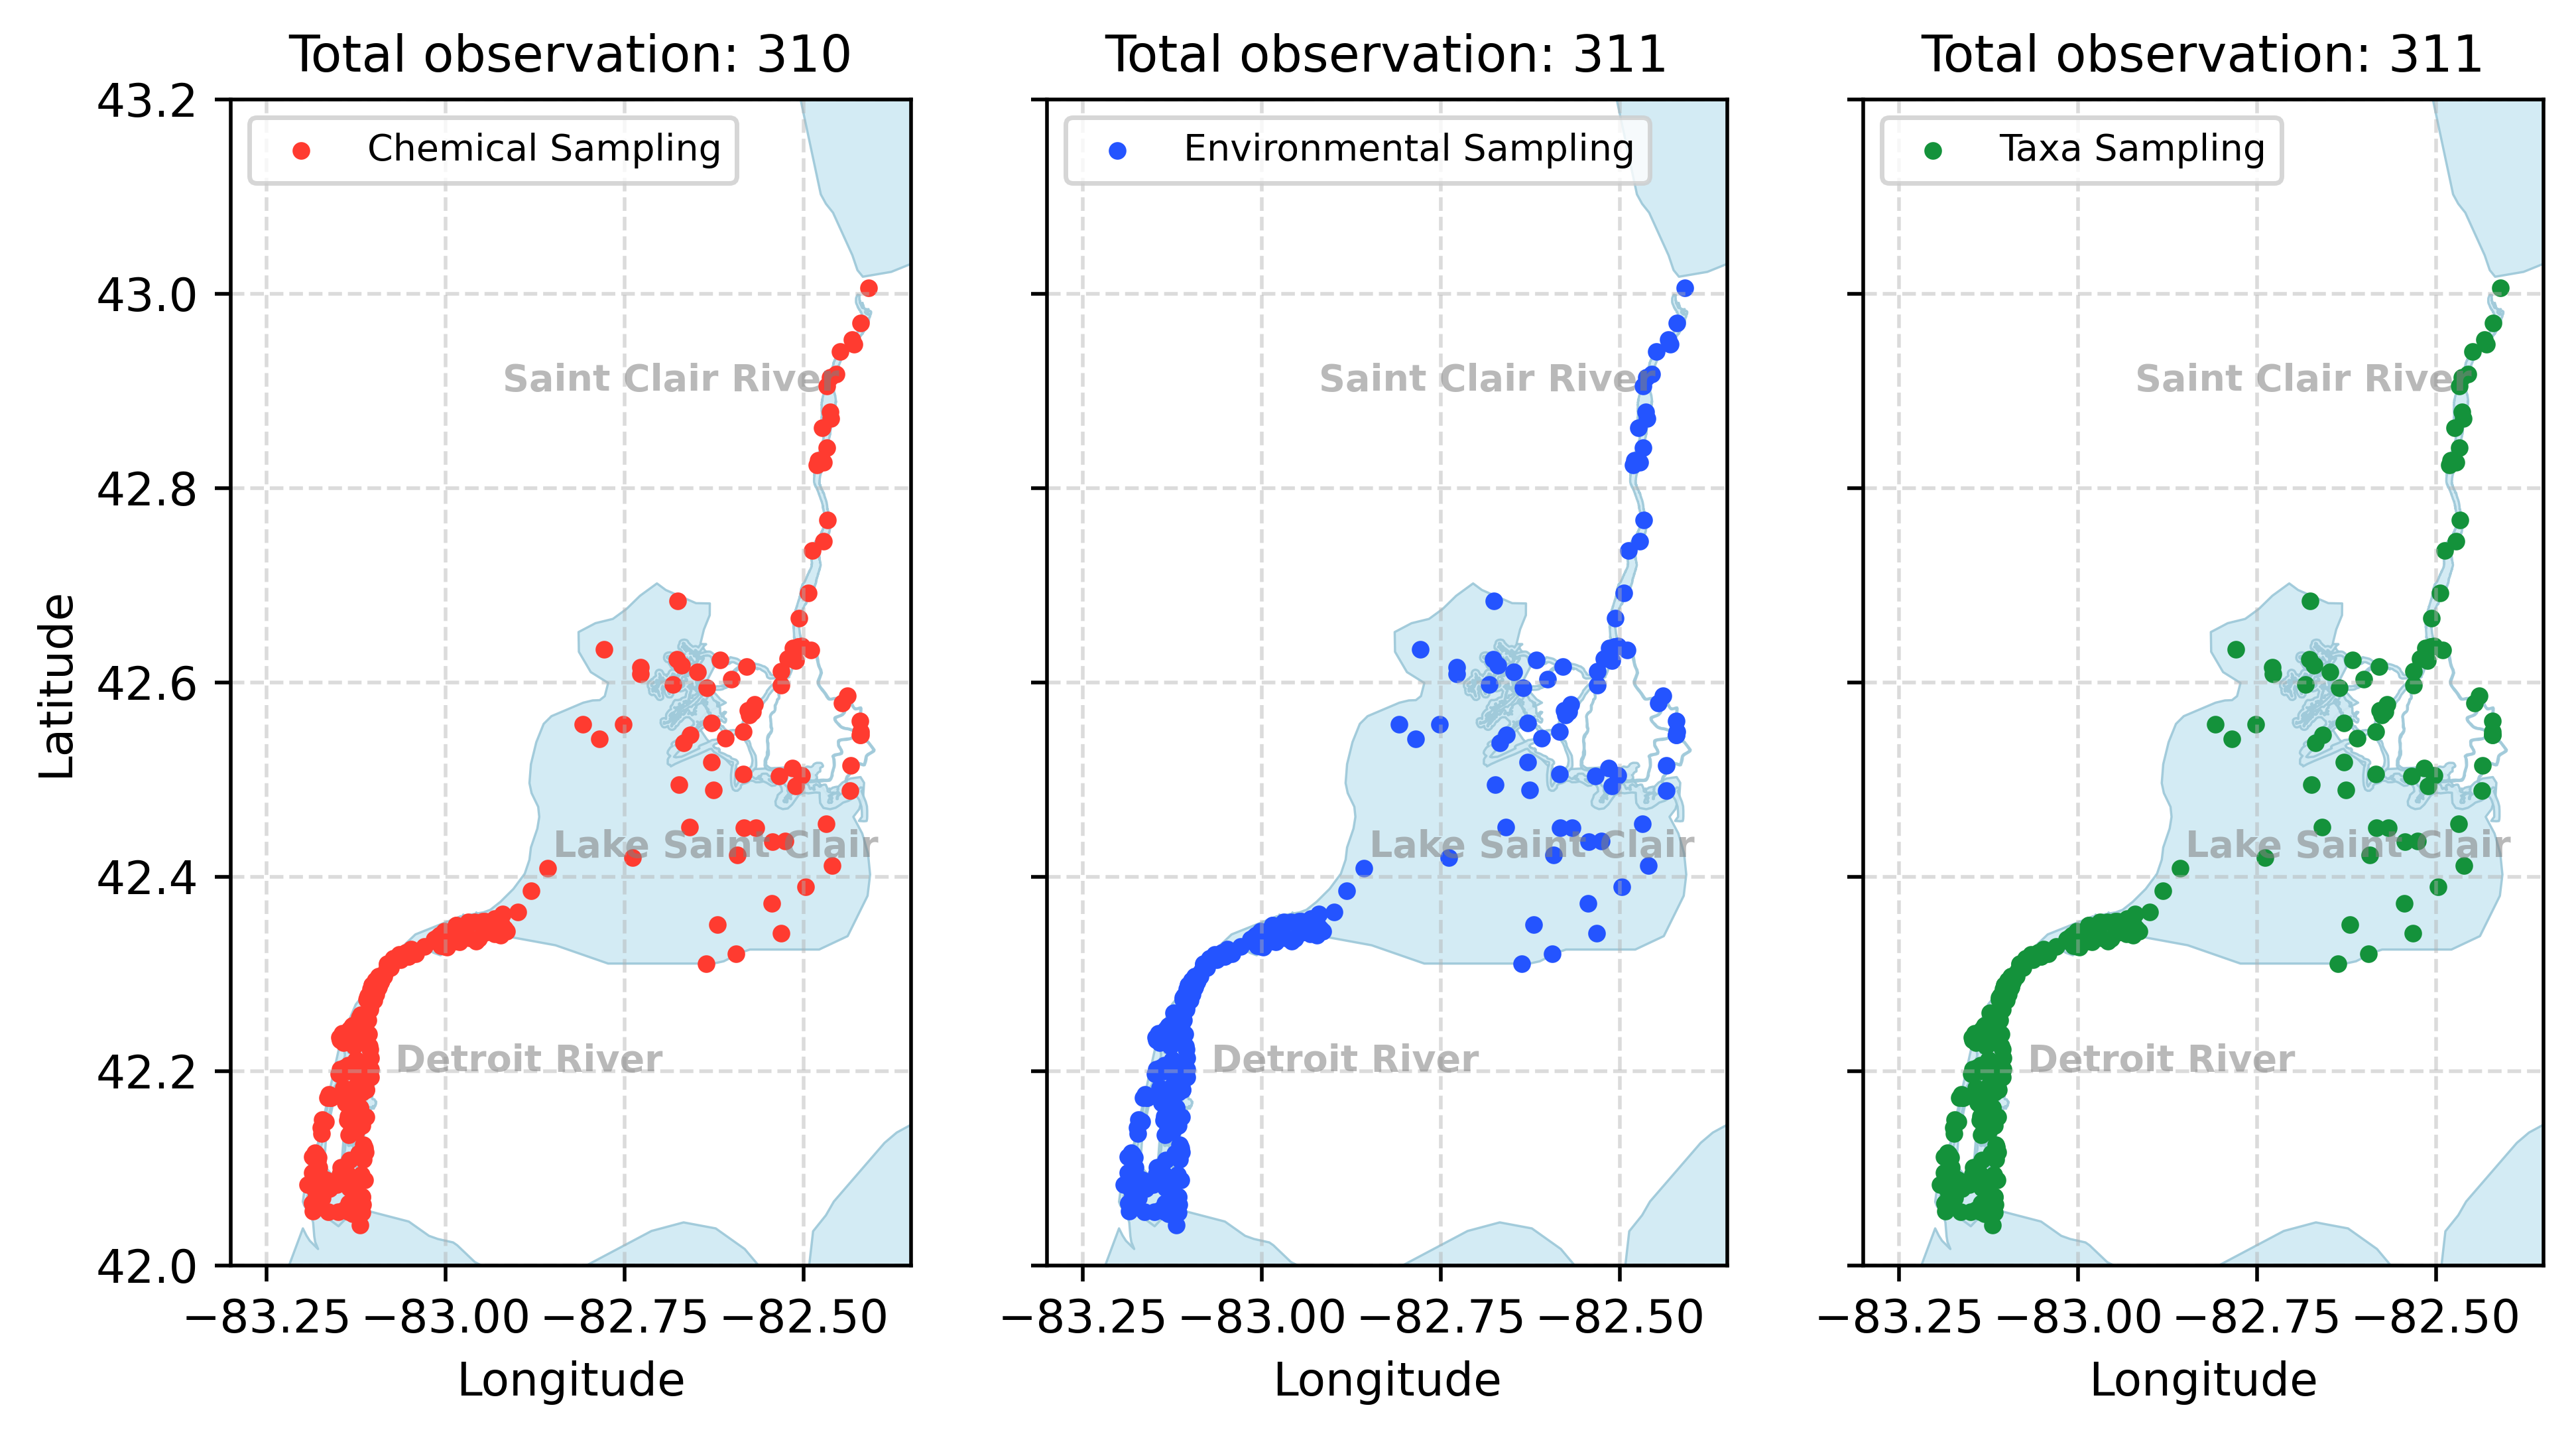

In [10]:
fig_master = plot_sampling_locations(
    master_merged_mapped,
    'Sampling locations for the master-based merged dataset',
)
# fig_master.savefig(PROCESSED_DIR / 'merged_complete_sampling_locations.png', dpi=500)
plt.show()

## 1991 Unit Harmonization and Detection-Limit Filling

This section shows the mapped 1991 chemicals from the transposed third sheet, the unit scaling used to bring concentrations onto the project merge scale, and the reproducible fills used for `-` non-detect values before the 1991 data are merged into the final workbook.

In [11]:
unit_summary_display = chemical_1991_unit_summary[
    [
        'source_name',
        'canonical_var',
        'source_unit',
        'target_unit',
        'scale_factor',
        'detection_limit_source',
        'detection_limit_target',
        'under_detection_count',
        'filled_count',
    ]
].copy()

print('1991 unit harmonization summary')
display(unit_summary_display)

print('1991 under-detection fill summary')
display(chemical_1991_fill_summary)

print('First 20 filled 1991 non-detect values used before merging')
display(chemical_1991_fill_examples.head(20))

1991 unit harmonization summary


,source_name,canonical_var,source_unit,target_unit,scale_factor,detection_limit_source,detection_limit_target,under_detection_count,filled_count
0,TOC,%OC,%,%,1.000,NaN,NaN,0,0
1,ALUMINUM,Al,mg/g,mg/kg,1000.000,NaN,NaN,0,0
2,ARSENIC,As,µg/g,mg/kg,1.000,NaN,NaN,0,0
3,CALCIUM,Ca,mg/g,mg/kg,1000.000,NaN,NaN,0,0
4,CADMIUM,Cd,µg/g,mg/kg,1.000,0.05,0.050,2,2
5,COBALT,Co,µg/g,mg/kg,1.000,NaN,NaN,0,0
6,CHROMIUM,Cr,µg/g,mg/kg,1.000,NaN,NaN,0,0
7,COPPER,Cu,µg/g,mg/kg,1.000,NaN,NaN,0,0
8,IRON,Fe,mg/g,mg/kg,1000.000,0.20,200.000,0,0
9,MERCURY,Hg,µg/g,mg/kg,1.000,0.01,0.010,1,1


1991 under-detection fill summary


,source_name,canonical_var,target_unit,detection_limit_target,under_detection_count,filled_count,imputed_min,imputed_max
0,CADMIUM,Cd,mg/kg,0.050,2,2,0.014197,0.021863
1,MERCURY,Hg,mg/kg,0.010,1,1,0.001583,0.001583
2,OCTACHLOROSTYRENE,OCS,mg/kg,0.001,63,63,0.000011,0.000480
3,"p,p'-DDE","p,p'-DDE",mg/kg,0.001,52,52,0.000020,0.000500
4,PCBs,total PCB,mg/kg,0.020,45,45,0.000220,0.009189


First 20 filled 1991 non-detect values used before merging


,StationID,canonical_var,source_name,target_unit,detection_limit,filled_value
0,47FB,Cd,CADMIUM,mg/kg,0.050,0.021863
1,84FB,Cd,CADMIUM,mg/kg,0.050,0.014197
2,47FB,Hg,MERCURY,mg/kg,0.010,0.001583
3,10FB,OCS,OCTACHLOROSTYRENE,mg/kg,0.001,0.000250
4,12FB,OCS,OCTACHLOROSTYRENE,mg/kg,0.001,0.000242
5,13FB,OCS,OCTACHLOROSTYRENE,mg/kg,0.001,0.000132
6,14FB,OCS,OCTACHLOROSTYRENE,mg/kg,0.001,0.000037
7,15FB,OCS,OCTACHLOROSTYRENE,mg/kg,0.001,0.000363
8,186FB,OCS,OCTACHLOROSTYRENE,mg/kg,0.001,0.000435
9,189FB,OCS,OCTACHLOROSTYRENE,mg/kg,0.001,0.000287
